# Feature Ingeniering

La ingeniería de características (o feature engineering) es el proceso de usar el conocimiento del dominio para crear, transformar, seleccionar o extraer variables (características) a partir de los datos crudos, con el objetivo de que un modelo de machine learning pueda aprender de forma más efectiva.

En otras palabras: es el arte y la ciencia de convertir datos crudos en representaciones útiles para un algoritmo.

Abarca diversas actividades:
| Actividad | Descripción | Ejemplo |
| :--- | :--- | :--- |
| **Creación** | Generar nuevas variables a partir de las existentes | edad², ingresos/deuda, hora del día a partir de un timestamp |
| **Transformación** | Cambiar la escala o distribución de una variable | Normalizar, estandarizar, aplicar logaritmo |
| **Codificación** | Convertir variables categóricas o textuales en numéricas | One-hot encoding, label encoding, embeddings |
| **Extracción** | Derivar características de datos complejos | Sacar bordes de una imagen, TF-IDF de un texto |
| **Selección** | Elegir las variables más relevantes y descartar el ruido | Eliminar variables correlacionadas, usar importancia de features |
| **Reducción** | Comprimir la información en menos dimensiones | PCA, t-SNE, autoencoders |

## El problema de clasificación del XOR

Las salidas de la compuerta XOR no son linealmente separables, por tanto no se pueden clasificar con el percepron simple si usamos la funcion de activacion escalon (step function), la solucion es usar una red neuronal mas avanzada con otra función de activación y posiblemente mas neuronas.

Otra solución es la que exploraremos en este documento y consiste en aplicar ingeniería de características (feature ingeniering), lo que haremos será mandar nuestra funcion a una dimension mas alta aplicando una funcion que llamamos kernel.

Primero veamos la grafica de las salidas de XOR para que nos de luz sobre el problema:

## Salidas del XOR

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Puntos de entrada (x, y) y su salida XOR
puntos = [(0, 0), (0, 1), (1, 0), (1, 1)]
salidas = [x ^ y for x, y in puntos]  # XOR

# Separar puntos por salida
x0 = [p[0] for p, s in zip(puntos, salidas) if s == 0]
y0 = [p[1] for p, s in zip(puntos, salidas) if s == 0]
x1 = [p[0] for p, s in zip(puntos, salidas) if s == 1]
y1 = [p[1] for p, s in zip(puntos, salidas) if s == 1]

# --- Gráfica en el plano X-Y ---
fig, ax = plt.subplots(figsize=(7, 7))

# Regiones de fondo (opcional, para visualizar mejor)
ax.axhspan(-0.5, 0.5, xmin=0, xmax=1, color='#ffe6e6', alpha=0.4)  # salida 0
ax.axhspan(0.5, 1.5, xmin=0, xmax=1, color='#e6ffe6', alpha=0.4)   # salida 1

# Dibujar los puntos
ax.scatter(x0, y0, s=400, color='#e74c3c', edgecolor='black',
           label='Salida = 0', zorder=3)
ax.scatter(x1, y1, s=400, color='#2ecc71', edgecolor='black',
           label='Salida = 1', zorder=3)

# Etiquetar cada punto con su valor de salida
for (x, y), s in zip(puntos, salidas):
    ax.annotate(str(s), (x, y), color='white', fontsize=13,
                fontweight='bold', ha='center', va='center', zorder=4)

# Líneas separadoras (fronteras entre regiones 0 y 1)
ax.plot([0, 1], [0.5, 0.5], 'k--', linewidth=1, alpha=0.6)
ax.plot([0.5, 0.5], [0, 1], 'k--', linewidth=1, alpha=0.6)

# Configuración de los ejes
ax.set_xlim(-0.3, 1.3)
ax.set_ylim(-0.3, 1.3)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xlabel("Entrada A (x)", fontsize=12)
ax.set_ylabel("Entrada B (y)", fontsize=12)
ax.set_title("Compuerta XOR en el plano X-Y", fontsize=14, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='upper right', fontsize=10)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

Como se puede apreciar en la gráfica 2D no se puede trazar una línea que separe los puntos 'verdes' de los puntos 'rojos'. **Esta función no es linealmnte separable**

## Solución

Elevar las salidas del XOR a una dimension superior, 3D en este caso, agregando una característica que haga los puntos linealmente separables, para este caso supongamos que las entradas del XOR (nuestras características) son $(x_1,x_2)$ agreguemos la característica $z$, con lo tendremos las caracteristicas en 3D $(x_1,x_2,z)$ donde $z=x_1*x_2$, grafiquemos estas características:

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Datos
X1 = np.array([0, 0, 1, 1])
X2 = np.array([0, 1, 0, 1])
#Z = X1 * X2  # Característica creada
Z=(X1 - X2) ** 2
Y = np.array([0, 1, 1, 0])  # Salida esperada

# Crear figura 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Colores según la salida
colors = ['red' if y == 0 else 'green' for y in Y]

# Dibujar puntos
scatter = ax.scatter(X1, X2, Z, c=colors, s=200,
                     edgecolors='black', linewidth=2, depthshade=True)

# Añadir etiquetas a los puntos
for i in range(len(X1)):
    ax.text(X1[i], X2[i], Z[i],
            f'({X1[i]},{X2[i]},{Z[i]})\nY={Y[i]}',
            fontsize=10, ha='center')

# Dibujar el plano que aprende el perceptrón:
# Fórmula: -0.5 + 1·X1 + 1·X2 - 2·Z = 0  →  Z = 0.5 + 0.5·X1 + 0.5·X2
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 10),
                     np.linspace(-0.5, 1.5, 10))
zz = 0.5 + 0.5*xx + 0.5*yy  # Plano de separación

ax.plot_surface(xx, yy, zz, alpha=0.3, color='blue',
                label='Plano de separación')

# Configurar ejes
ax.set_xlabel('X1', fontsize=12, fontweight='bold')
ax.set_ylabel('X2', fontsize=12, fontweight='bold')
ax.set_zlabel('Z = (X1-X2)**2', fontsize=12, fontweight='bold')
ax.set_title('Perceptrón XOR - Ingeniería de Características en 3D',
             fontsize=14, fontweight='bold')

# Leyenda personalizada
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='Y = 0 (Clase 0)'),
                   Patch(facecolor='green', label='Y = 1 (Clase 1)'),
                   Patch(facecolor='blue', alpha=0.3, label='Plano separador')]
ax.legend(handles=legend_elements, loc='upper left')

# Ángulo de vista para mejor visualización
ax.view_init(elev=25, azim=-60)

plt.tight_layout()
plt.show()

Como puede ver ahora son línealmente separables.

¿Como fue esto?

Respuesta: al agregar la nueva caractéristica $(x_1,x_2,x_1 \cdot x_2)$ estamos elevando nuestra funcion a 3D, agregando una nueva característica, sea $z=x_1 \cdot x_2$.

Observe que para la tabla del XOR con la nueva característica $(x_1,x_2,z)$ tenemos:
|$x_1$ |$x_2$   | $z=x_1 \cdot x_2$   | XOR |
|:----:|:------:|:-------------------:|:-----:|
|0     |0    |&nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; 0 &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;| 0|
|0     |1    |1 | 1|
|1     |0    |1 | 1|
|1     |1    |0 | 0|

Es la tabla de XOR que ya conoce, solo se agrega la columna $z$, los valores de las coordenadas $x_1 , x_2$ siguen siendo los mismos, pero ahora en la tercera coordenada $z$, al multiplicar $x_1 \cdot x_2$, la coordenada $(z)$ hace una diferencia entre las coordenadas $x_1 , x_2$ y en la tercera dimencion ($z$), las salidas del XOR correspondientes a 1 estaran por encima de las salidas correspondientes a 0 que quedan 'abajo', por lo que ahora podemos encontrar un plano que separe ambas clases de salidas del XOR clases {0,1}.

**Ahora son linealmente separables.**

## Código en python

In [ ]:
import numpy as np

# ============================================================
# Feature engineering (XOR con término de interacción x1*x2)
# ============================================================
X_base = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
x3 = (X_base[:, 0] * X_base[:, 1]).reshape(-1, 1)
X = np.hstack([X_base, x3])
y = np.array([[0], [1], [1], [0]], dtype=float)

# ============================================================
# Inicialización del perceptrón
# ============================================================
np.random.seed(0)
w = np.random.randn(3, 1) * 0.1
b = np.zeros((1,))
lr = 0.5

# ============================================================
# Entrenamiento
# ============================================================
for epoch in range(2000):
    # 1) Pre-activación lineal
    z = X @ w + b

    # 2) Activación ESCALÓN (step function)
    y_hat = (z > 0).astype(float)

    # 3) Error
    error = y_hat - y

    # 4) Actualización de pesos
    w -= lr * (X.T @ error) / len(X)
    b -= lr * error.mean()

    # 5) Pérdida MCE (Mean Squared Error)
    loss = (error ** 2).mean()

    print(f"Época {epoch+1:4d} -> loss (MSE): {loss:.4f}", end='\r')

# ============================================================
# Resultados
# ============================================================
print("\n\nPesos finales:")
print(f"  w1={w[0][0]:+.4f}, w2={w[1][0]:+.4f}, w3={w[2][0]:+.4f}, b={b[0]:+.4f}")

print("\nPredicciones:")
for i in range(len(X)):
    z_i = (X[i] @ w + b)[0]
    p = 1.0 if z_i > 0 else 0.0
    print(f"  {X[i]} -> {int(p)} (z={z_i:+.4f})")

Grafica con la nueva característica.

## Código en python con activación sigmoide y funcionde perdida cross entropy

Usando la funcion de activación sigmoide:
$$σ(z)= \frac {1}{1+e^{-z}}$$

```text
σ(z)
 1 │           ___________
   │         /
0.5│--------●-------------
   │       /
 0 │______/
   └──────────────────────→ z
   -6  -4  -2  0  2  4  6
```

Y la función de perdida (Binary Cross-Entropy):


\begin{equation}
\mathcal{L} = -\frac{1}{n} \sum_{i=1}^{n}
\left[ y_i \cdot \log(\hat{y}_i + \varepsilon) + (1 - y_i) \cdot \log(1 - \hat{y}_i + \varepsilon) \right]
\end{equation}

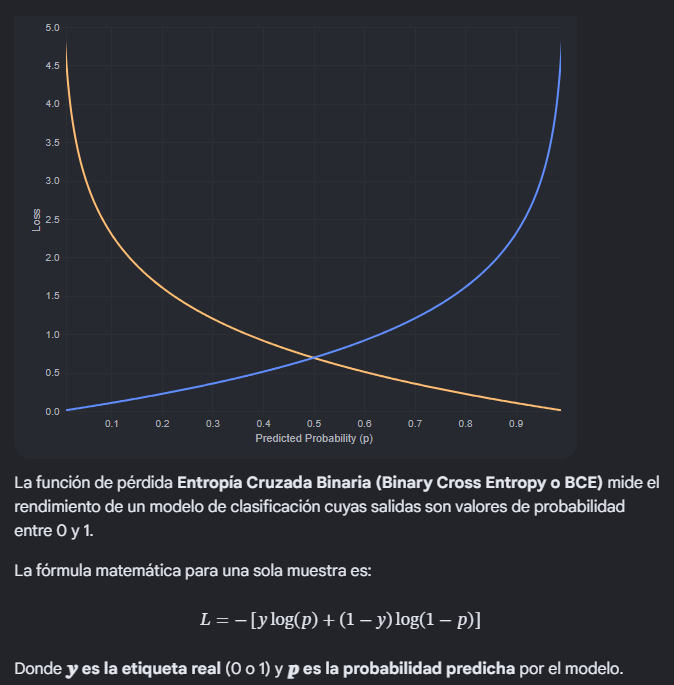


Comportamiento de la gráfica:
* Cuando la clase real es \(y = 1\) (Línea descendente): Si el modelo predice una probabilidad cercana a 1, la pérdida es casi 0. Pero a medida que la probabilidad predicha se acerca a 0, la pérdida penaliza drásticamente al modelo, tendiendo al infinito.
* Cuando la clase real es \(y = 0\) (Línea ascendente): Si el modelo predice correctamente una probabilidad cercana a 0, la pérdida es 0. Si el modelo se equivoca y predice una probabilidad cercana a 1, la penalización sube exponencialmente hacia el infinito.

## Actualización de pesos:
$$w^{nuevo} =w^{viejo} −η ⋅ \frac{∂loss}{∂w}$$

In [ ]:
import numpy as np

# Feature engineering
X_base = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
x3 = (X_base[:, 0] * X_base[:, 1]).reshape(-1, 1)
X = np.hstack([X_base, x3])
y = np.array([[0],[1],[1],[0]], dtype=float)

# Perceptrón
np.random.seed(0)
w = np.random.randn(3, 1) * 0.1
b = np.zeros((1,))
lr = 0.5

for epoch in range(2000):
    z = X @ w + b # @ es la multiplicacion matricial (producto punto)
    y_hat = 1 / (1 + np.exp(-z))
    error = y_hat - y
    w -= lr * (X.T @ error) / len(X) # transpuesta de x * error
    b -= lr * error.mean()
    loss = -(y * np.log(y_hat + 1e-9) + (1 - y) * np.log(1 - y_hat + 1e-9)).mean()
    print(f"Época {epoch+1:4d} -> loss: {loss:.4f}", end='\r')

print("\n\nPesos finales:")
print(f"  w1={w[0][0]:+.4f}, w2={w[1][0]:+.4f}, w3={w[2][0]:+.4f}, b={b[0]:+.4f}")

print("\nPredicciones:")
for i in range(len(X)):
    p = 1 / (1 + np.exp(-(X[i] @ w + b)))[0]
    print(f"  {X[i]} -> {1 if p > 0.5 else 0} (prob={p:.4f})")

# Actualizacion de los pesos

$$w_{i} = w_{i} - \eta \cdot \frac{\partial L}{\partial w_{i}}$$

$$w_{i} = w_{i} - \eta \cdot (p - y) \cdot x_{i}$$

X.T @ error` (la clave del gradiente) **acumula** $x_i \cdot (p - y)$ sobre todas las muestras.